<a href="https://colab.research.google.com/github/niinog/Alzheimer-s-detection-project/blob/main/Kaggle_MRI_Alzheimers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the Parquet Files

## Load the specified parquet file

### Subtask:
Convert from bytes to pixel brightness



**Reasoning**:
Update the file path in the existing code cell to load the specified parquet file and execute the cell.



## Inspect the dataframe

### Subtask:
Save to pandas df



**Reasoning**:
Display the column names, data types, and first few rows of the DataFrame to understand its structure and the nature of the image data.



## Extract and display images

### Subtask:
Based on the DataFrame structure, write code to extract the image data (e.g., if it's in a specific column) and display the images. This might require using libraries like Pillow or OpenCV.


**Reasoning**:
Import PIL and iterate through the first few rows of the dataframe to extract and display the images.



In [ ]:
# Ensure pyarrow is installed in this kernel
!pip install --quiet pyarrow
!pip install pandas Pillow kagglehub ipywidgets numpy matplotlib pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.4 MB/s eta 0:00:00


In [ ]:
import copy
import random
from dataclasses import dataclass
from typing import Optional, Dict, Tuple
from PIL import Image
import io

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import v2 as T
from torchvision.models import (
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights,
    resnet50, ResNet50_Weights
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix

In [ ]:

train_df = pd.read_parquet("/content/train.parquet")
test_df  = pd.read_parquet("/content/test.parquet")

def bytes_to_pixels(b: bytes) -> np.ndarray:
    """
    Convert raw image bytes (e.g. JPEG/PNG) into a 2D numpy array of pixel values (grayscale).
    """
    img = Image.open(io.BytesIO(b))  # convert to grayscale
    return np.array(img)
def extract_bytes(blob):
    """
    Unwrap a dict‐wrapped binary payload if needed,
    otherwise return blob directly.
    """
    if isinstance(blob, dict):
        # try common keys
        for key in ("bytes", "data", "image"):
            if key in blob and isinstance(blob[key], (bytes, bytearray)):
                return blob[key]
        # fallback: first bytes‐like value
        for v in blob.values():
            if isinstance(v, (bytes, bytearray)):
                return v
        raise TypeError(f"No bytes found in dict payload: {list(blob.keys())}")
    return blob

train_df["image"] = train_df["image"].apply(lambda blob: bytes_to_pixels(extract_bytes(blob)))
test_df["image"]  = test_df["image"].apply(lambda blob: bytes_to_pixels(extract_bytes(blob)))




1. label = 2


/tmp/ipython-input-4051836937.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels.astype("uint8"), mode="L")


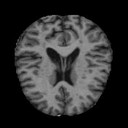

2. label = 0


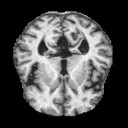

3. label = 3


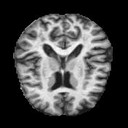

4. label = 3


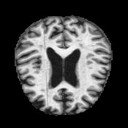

5. label = 2


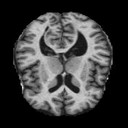

6. label = 2


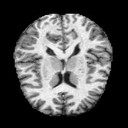

7. label = 2


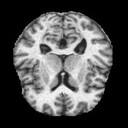

8. label = 2


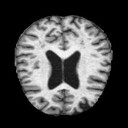

9. label = 3


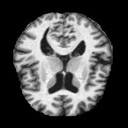

10. label = 2


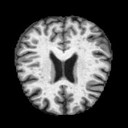

In [ ]:
def display_images(df, n=10):
    """
    Display the first n grayscale images (numpy arrays) from df
    along with their labels. Assumes df has columns 'image' and 'label'.
    """
    for i, (_, row) in enumerate(df.head(n).iterrows(), start=1):
        pixels = row["image"]
        label = row.get("label", "")
        # Create a PIL image in 'L' mode (8-bit pixels, black and white)
        img = Image.fromarray(pixels.astype("uint8"), mode="L")
        print(f"{i}. label = {label}")
        display(img)
display_images(train_df)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   5120 non-null   object
 1   label   5120 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 80.1+ KB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   1280 non-null   object
 1   label   1280 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 20.1+ KB


In [ ]:
train_df['label'].value_counts()

,count
label,
2,2566
3,1781
0,724
1,49


In [ ]:
test_df['label'].value_counts()

,count
label,
2,634
3,459
0,172
1,15


In [ ]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
@dataclass
class CFG:
    seed: int = 42
    num_classes: int = 4
    img_size: int = 128
    batch_size: int = 64
    num_workers: int = 0
    epochs: int = 20

    model_name: str = "densenet121"  # "efficientnet_b0", "convnext_tiny", "resnet50"

    # Optimization
    lr: float = 3e-4
    weight_decay: float = 1e-4
    max_grad_norm: float = 1.0

    # Imbalance strategy
    use_sampler: bool = False
    use_focal: bool = False
    focal_gamma: float = 1.5
    label_smoothing: float = 0.05

    # Freezing
    freeze_backbone_epochs: int = 1

    # Early stopping
    patience: int = 5

In [ ]:
def compute_grayscale_mean_std_from_df(df: pd.DataFrame) -> Tuple[float, float]:
    # df["image"] contains np arrays (H,W)
    # We assume pixel values either 0..255 or 0..1
    means = []
    sq_means = []
    for arr in df["image"].values:
        x = arr.astype(np.float32)
        if x.max() > 1.0:
            x /= 255.0
        means.append(x.mean())
        sq_means.append((x ** 2).mean())
    mean = float(np.mean(means))
    mean_sq = float(np.mean(sq_means))
    var = max(mean_sq - mean**2, 1e-6)
    std = float(np.sqrt(var))
    return mean, std

In [ ]:
class MRIDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        x = self.df.loc[idx, "image"]  # np array (H,W)
        y = int(self.df.loc[idx, "label"])

        x = x.astype(np.float32)
        if x.max() > 1.0:
            x /= 255.0

        # (H,W) -> (1,H,W) -> (3,H,W)
        x = torch.from_numpy(x).unsqueeze(0).repeat(3, 1, 1)

        if self.transform is not None:
            x = self.transform(x)

        return x, y


In [ ]:
def get_transforms(img_size: int, mean: float, std: float):
    mean3 = (mean, mean, mean)
    std3  = (std, std, std)

    train_tfms = T.Compose([
        T.Resize((img_size, img_size)),
        T.RandomRotation(8),
        T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.98, 1.02)),
        T.Normalize(mean=mean3, std=std3),
    ])

    val_tfms = T.Compose([
        T.Resize((img_size, img_size)),
        T.Normalize(mean=mean3, std=std3),
    ])
    return train_tfms, val_tfms


In [ ]:
def build_model(model_name: str, num_classes: int) -> nn.Module:
    mn = model_name.lower()

    if mn == "densenet121":
        m = densenet121(weights=DenseNet121_Weights.DEFAULT)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
        return m

    if mn == "efficientnet_b0":
        m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m

    if mn == "convnext_tiny":
        m = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)
        return m

    if mn == "resnet50":
        m = resnet50(weights=ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m

    raise ValueError(f"Unsupported model_name={model_name}")


def freeze_backbone(model: nn.Module, model_name: str, freeze: bool = True):
    for p in model.parameters():
        p.requires_grad = not freeze

    mn = model_name.lower()
    # Re-enable head
    if mn == "densenet121":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif mn == "efficientnet_b0":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif mn == "convnext_tiny":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif mn == "resnet50":
        for p in model.fc.parameters():
            p.requires_grad = True

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, weight: Optional[torch.Tensor] = None, gamma: float = 1.5):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ce = nn.functional.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def make_class_weights(labels: np.ndarray, num_classes: int, device: torch.device) -> torch.Tensor:
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    weights = counts.sum() / (counts + 1e-6)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=device)

In [ ]:
@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)


def metrics_dict(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "bal_acc": float(balanced_accuracy_score(y_true, y_pred)),
    }


def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, scaler, cfg: CFG):
    model.train()
    total = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)

        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        bs = x.size(0)
        total += loss.item() * bs
        n += bs

    return total / max(n, 1)

In [ ]:
def fit(train_df: pd.DataFrame, test_df: pd.DataFrame, cfg: CFG):
    seed_everything(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # -------------------------
    # 1) Train/Val split
    # -------------------------
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=cfg.seed)
    idx_tr, idx_va = next(splitter.split(train_df, train_df["label"].values))
    df_tr = train_df.iloc[idx_tr].reset_index(drop=True)
    df_va = train_df.iloc[idx_va].reset_index(drop=True)

    print("Train split counts:\n", df_tr["label"].value_counts().sort_index())
    print("Val split counts:\n", df_va["label"].value_counts().sort_index())
    if "label" in test_df.columns:
        print("Test counts:\n", test_df["label"].value_counts().sort_index())

    # -------------------------
    # 2) Mean/Std from TRAIN
    # -------------------------
    mean, std = compute_grayscale_mean_std_from_df(df_tr)
    print(f"Computed MRI mean/std: {mean:.4f} / {std:.4f}")

    train_tfms, val_tfms = get_transforms(cfg.img_size, mean, std)

    ds_tr = MRIDataset(df_tr, transform=train_tfms)
    ds_va = MRIDataset(df_va, transform=val_tfms)
    ds_te = MRIDataset(test_df, transform=val_tfms)  # if test has labels, ok; if not, dataset should handle it

    labels_tr = df_tr["label"].values.astype(int)

    # -------------------------
    # 3) (Optional) Sampler
    # -------------------------
    sampler = None
    if cfg.use_sampler:
        class_counts = np.bincount(labels_tr, minlength=cfg.num_classes)
        class_w = 1.0 / (class_counts + 1e-6)
        sample_w = class_w[labels_tr]
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_w, dtype=torch.double),
            num_samples=len(sample_w),
            replacement=True
        )

    dl_tr = DataLoader(
        ds_tr,
        batch_size=cfg.batch_size,
        shuffle=(sampler is None),
        sampler=sampler,
        num_workers=cfg.num_workers,
        pin_memory=True
    )
    dl_va = DataLoader(ds_va, batch_size=cfg.batch_size, shuffle=False,
                       num_workers=cfg.num_workers, pin_memory=True)
    dl_te = DataLoader(ds_te, batch_size=cfg.batch_size, shuffle=False,
                       num_workers=cfg.num_workers, pin_memory=True)

    # -------------------------
    # 4) Model (DenseNet121)
    # -------------------------
    assert cfg.model_name.lower() == "resnet50", "This fit() is configured for ResNet50."

    # Load ResNet50 with pretrained ImageNet weights
    model = resnet50(weights='IMAGENET1K_V1')

    # Replace the final fully connected layer for your num_classes
    model.fc = nn.Linear(model.fc.in_features, cfg.num_classes)

    model = model.to(device)

    # -------------------------
    # 5) Loss
    # -------------------------
    class_weights = make_class_weights(labels_tr, cfg.num_classes, device=device)
    if cfg.use_sampler:
        # sampler already balances batches; weights can overcompensate
        class_weights = None

    if cfg.use_focal:
        criterion = FocalLoss(weight=class_weights, gamma=cfg.focal_gamma)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg.label_smoothing)

    # -------------------------
    # 6) Optim / Sched / AMP
    # -------------------------
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    steps_per_epoch = max(1, len(dl_tr))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.lr,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.1
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    # -------------------------
    # 7) Train loop + early stop
    # -------------------------
    best = {"macro_f1": -1.0, "state": None}
    patience_left = cfg.patience

    # warmup freeze backbone
    if cfg.freeze_backbone_epochs > 0:
        freeze_backbone(model, cfg.model_name, freeze=True)

    for epoch in range(1, cfg.epochs + 1):
        if cfg.freeze_backbone_epochs > 0 and epoch == cfg.freeze_backbone_epochs + 1:
            freeze_backbone(model, cfg.model_name, freeze=False)

        tr_loss = train_one_epoch(model, dl_tr, optimizer, scheduler, criterion, device, scaler, cfg)

        yv, pv = predict(model, dl_va, device)
        m = metrics_dict(yv, pv)

        print(
            f"Epoch {epoch:02d}/{cfg.epochs} | "
            f"train_loss={tr_loss:.4f} | "
            f"val_macroF1={m['macro_f1']:.4f} | "
            f"val_balAcc={m['bal_acc']:.4f}"
        )

        if m["macro_f1"] > best["macro_f1"] + 1e-4:
            best["macro_f1"] = m["macro_f1"]
            best["state"] = copy.deepcopy(model.state_dict())
            patience_left = cfg.patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping.")
                break

    if best["state"] is not None:
        model.load_state_dict(best["state"])

    # -------------------------
    # 8) Test evaluation
    # -------------------------
    if "label" in test_df.columns:
        yt, pt = predict(model, dl_te, device)
        print("\n===== TEST RESULTS =====")
        print("Macro F1:", f1_score(yt, pt, average="macro"))
        print("Balanced Accuracy:", balanced_accuracy_score(yt, pt))
        print("\nClassification Report:\n", classification_report(yt, pt, digits=4))
        print("Confusion Matrix:\n", confusion_matrix(yt, pt))

    # return trained model + useful objects for Grad-CAM later
    return {
        "model": model,
        "device": device,
        "df_tr": df_tr,
        "df_va": df_va,
        "mean": mean,
        "std": std,
        "train_tfms": train_tfms,
        "val_tfms": val_tfms,
        "ds_va": ds_va,   # <-- so ds_va exists when you run Grad-CAM
        "dl_va": dl_va
    }


In [ ]:
cfg = CFG(
    model_name="resnet50",
    img_size=128,
    batch_size=64,
    lr=3e-4,
    epochs=50,
    use_sampler=False,
    use_focal=False,
    label_smoothing=0.05,
    freeze_backbone_epochs=1,
    num_workers=0
)

out = fit(train_df, test_df, cfg)

Device: cuda
Train split counts:
 label
0     615
1      42
2    2181
3    1514
Name: count, dtype: int64
Val split counts:
 label
0    109
1      7
2    385
3    267
Name: count, dtype: int64
Test counts:
 label
0    172
1     15
2    634
3    459
Name: count, dtype: int64
Computed MRI mean/std: 0.2783 / 0.3267
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]
/tmp/ipython-input-2691552227.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipython-input-684683176.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/50 | train_loss=1.8379 | val_macroF1=0.0435 | val_balAcc=0.2359


/tmp/ipython-input-684683176.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 02/50 | train_loss=1.6338 | val_macroF1=0.3908 | val_balAcc=0.6138


...

Epoch 42/50 | train_loss=0.8386 | val_macroF1=0.9783 | val_balAcc=0.9945


/tmp/ipython-input-684683176.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 43/50 | train_loss=0.8193 | val_macroF1=0.9641 | val_balAcc=0.9945


/tmp/ipython-input-684683176.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 44/50 | train_loss=0.8379 | val_macroF1=0.9649 | val_balAcc=0.9945
Early stopping.

===== TEST RESULTS =====
Macro F1: 0.9869319427218959
Balanced Accuracy: 0.9942760710280248

Classification Report:
               precision    recall  f1-score   support

           0     0.9942    0.9884    0.9913       172
           1     0.9375    1.0000    0.9677        15
           2     0.9953    0.9953    0.9953       634
           3     0.9935    0.9935    0.9935       459

    accuracy                         0.9938      1280
   macro avg     0.9801    0.9943    0.9869      1280
weighted avg     0.9938    0.9938    0.9938      1280

Confusion Matrix:
 [[170   0   0   2]
 [  0  15   0   0]
 [  1   1 631   1]
 [  0   0   3 456]]


# GRAD CAM

In [ ]:
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # Forward hook to store activations
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        # Backward hook to store gradients
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple
        self.gradients = grad_output[0]

    def remove(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def generate(self, x, class_idx=None):
        self.model.eval()
        x = x.requires_grad_()

        logits = self.model(x)
        pred_class = logits.argmax(dim=1).item()

        if class_idx is None:
            class_idx = pred_class

        # Zero existing gradients
        self.model.zero_grad()
        score = logits[:, class_idx]
        score.backward(retain_graph=False)

        # Compute weights from gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam, inplace=False)
        cam = F.interpolate(
            cam,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam[0, 0]
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy(), pred_class


In [ ]:
import matplotlib.pyplot as plt

def overlay_gradcam(image, cam, alpha=0.4, cmap="jet"):
    """
    image: original grayscale image (H, W)
    cam: Grad-CAM heatmap (H, W)
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image, cmap="gray")
    ax.imshow(cam, cmap=cmap, alpha=alpha)
    ax.axis("off")
    return fig

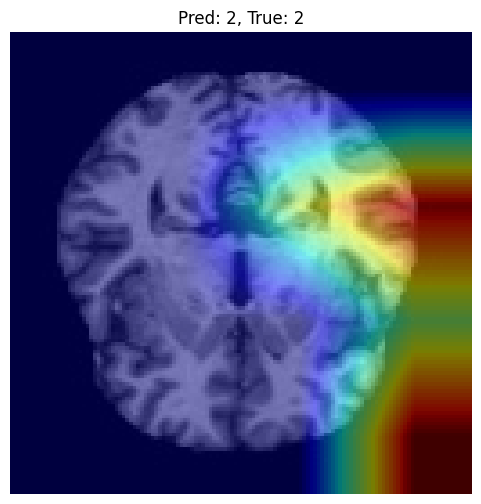

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1) Extract from fit() output
model  = out["model"]
device = out["device"]
ds_va  = out["ds_va"]
mean   = out["mean"]
std    = out["std"]

# 2) Set target layer for Grad-CAM
target_layer = model.layer4[-2].conv3
gradcam = GradCAM(model, target_layer)

# 3) Pick a sample image from validation set
x, label = ds_va[0]          # first image
x = x.unsqueeze(0).to(device)  # add batch dim and move to device

# 4) Generate Grad-CAM
cam, pred_class = gradcam.generate(x)

# 5) Visualize
img = x[0].detach().cpu().numpy().transpose(1,2,0)  # detach before .numpy()
img = img * std + mean  # unnormalize

plt.figure(figsize=(6,6))
plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(cam, cmap='jet', alpha=0.5)  # overlay CAM
plt.title(f"Pred: {pred_class}, True: {label}")
plt.axis('off')
plt.show()

# 6) Remove hooks
gradcam.remove()
